In [1]:
import math

import numpy as np
import matplotlib.pyplot as plt

# the same colours and line styles as the plots in the notes
STYLES = [dict(color="#3172AE", linestyle="-"),
          dict(color="#D55E00", linestyle="--"),
          dict(color="#404040", linestyle=":")]


# the curves fs against x, with a legend when there is more than one
def curves(x, fs, labels, title, xlabel="x", ylabel="f(x)"):
    fig, ax = plt.subplots(figsize=(6, 3.2), layout="constrained")
    for f, label, style in zip(fs, labels, STYLES):
        ax.plot(x, f, label=label, linewidth=2, **style)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_ylim(bottom=0)
    if len(fs) > 1:
        ax.legend()
    return ax


# the trapezoidal rule for the integral of the values y at the grid points x
def integrate(x, y):
    return np.sum((y[1:] + y[:-1]) / 2 * np.diff(x))


# compare the total probability, mean, and variance computed from the density values
# f at the grid x with the ones in the notes; the grid must be fine and must reach
# far enough that the probability left out is negligible
def check(x, f, mean, variance):
    total = integrate(x, f)
    mu = integrate(x, x * f)
    var = integrate(x, (x - mu)**2 * f)
    print(f"{'':12}{'from f(x)':>11}{'notes':>11}")
    print(f"{'total':12}{total:11.4f}{1:11.4f}")
    print(f"{'mean':12}{round(mu, 4) + 0:11.4f}{mean:11.4f}")   # + 0 turns -0.0 into 0.0
    print(f"{'variance':12}{var:11.4f}{variance:11.4f}")

# Common continuous distributions

This notebook collects the continuous distributions that come up most often in this
course (Appendix A of the notes). For each one we list its parameters, the density
$f_X(x)$, the mean $\mathbb{E}[X]$, the variance $\mathbb{V}[X]$, and the *moment
generating function* $M_X(t)=\mathbb{E}\bigl[e^{tX}\bigr]$, together with the values
of $t$ for which it is finite. The density is zero outside the values of $x$ listed.

**Disclaimer:** the definitions of the distributions are based on a writeup by
Prof. Dr. Subramanian Ramakrishnan at the University of Miami.

Each density is typed in from its formula in the notes, and each plot uses the same
parameters as the plot in the notes. Run the cells from top to bottom. Then change
the numbers in a cell and run it again to see how the distribution changes shape.

Below each plot, the code checks the formulas for one of the plotted parameter
choices: it integrates $f(x)$, $x\,f(x)$, and $(x-\mu)^2 f(x)$ numerically, with the
trapezoidal rule on a fine grid, and compares the results with 1 and with the mean
and variance in the notes.

## Uniform

Parameters $a<b$; $X$ is equally likely to fall anywhere in the interval $(a,b)$.

$$
f_X(x)=\frac{1}{b-a},\qquad a<x<b.
$$

* $\mathbb{E}[X]=\dfrac{a+b}{2}$
* $\mathbb{V}[X]=\dfrac{(b-a)^{2}}{12}$
* $M_X(t)=\dfrac{e^{tb}-e^{ta}}{(b-a)t}$ for $t\ne 0$, and $M_X(0)=1$

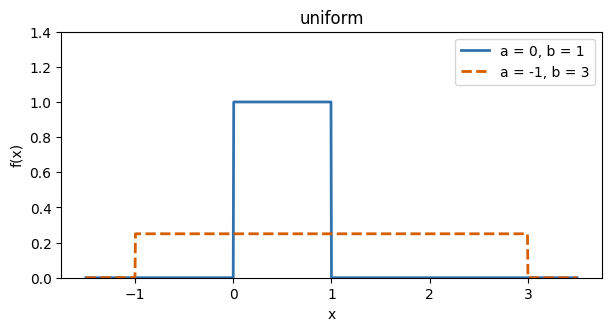

              from f(x)      notes
total            1.0000     1.0000
mean             1.0000     1.0000
variance         1.3333     1.3333


In [2]:
def uniform(x, a, b):
    return np.where((a < x) & (x < b), 1 / (b - a), 0.0)


x = np.linspace(-1.5, 3.5, 1001)
ax = curves(x, [uniform(x, 0, 1), uniform(x, -1, 3)],
            ["a = 0, b = 1", "a = -1, b = 3"], "uniform")
ax.set_ylim(0, 1.4)
plt.show()

a, b = -1, 3
x = np.linspace(a, b, 100001)
check(x, uniform(x, a, b), mean=(a + b) / 2, variance=(b - a)**2 / 12)

## Exponential

Rate $\lambda>0$; $X$ is the waiting time until the first event of a process with
rate $\lambda$.

$$
f_X(x)=\lambda e^{-\lambda x},\qquad x>0.
$$

* $\mathbb{E}[X]=\dfrac{1}{\lambda}$
* $\mathbb{V}[X]=\dfrac{1}{\lambda^{2}}$
* $M_X(t)=\dfrac{\lambda}{\lambda-t}$ for $t<\lambda$

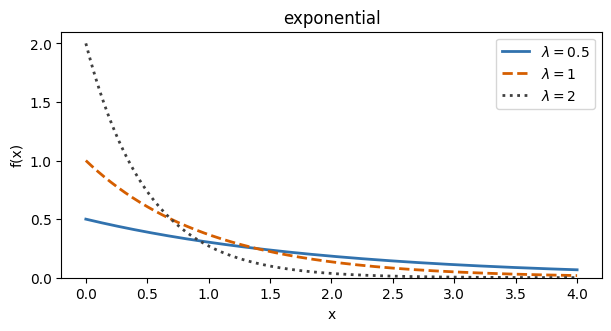

              from f(x)      notes
total            1.0000     1.0000
mean             2.0000     2.0000
variance         4.0000     4.0000


In [3]:
def exponential(x, lam):          # for x > 0; lambda is a reserved word in Python
    return lam * np.exp(-lam * x)


x = np.linspace(0, 4, 401)
curves(x, [exponential(x, 0.5), exponential(x, 1), exponential(x, 2)],
       [r"$\lambda = 0.5$", r"$\lambda = 1$", r"$\lambda = 2$"], "exponential")
plt.show()

lam = 0.5
x = np.linspace(0, 40 / lam, 200001)
check(x, exponential(x, lam), mean=1 / lam, variance=1 / lam**2)

## Gamma

Shape $\alpha>0$ and rate $\lambda>0$.

$$
f_X(x)=\frac{\lambda^{\alpha}}{\Gamma(\alpha)}\,x^{\alpha-1}e^{-\lambda x},\qquad x>0.
$$

* $\mathbb{E}[X]=\dfrac{\alpha}{\lambda}$
* $\mathbb{V}[X]=\dfrac{\alpha}{\lambda^{2}}$
* $M_X(t)=\Bigl(\dfrac{\lambda}{\lambda-t}\Bigr)^{\alpha}$ for $t<\lambda$

> Here $\Gamma(\alpha)=\int_0^{\infty}x^{\alpha-1}e^{-x}\,dx$ is the gamma function,
> with $\Gamma(k)=(k-1)!$ for $k=1,2,\dots$ and $\Gamma(1/2)=\sqrt{\pi}$. The
> exponential distribution is the gamma distribution with $\alpha=1$. Wasserman
> parametrizes the exponential and gamma distributions by the scale $\beta=1/\lambda$
> instead of the rate $\lambda$.

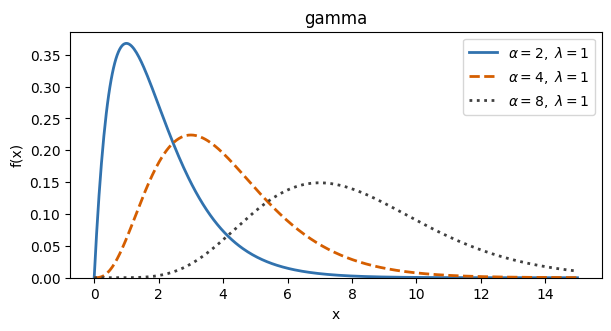

              from f(x)      notes
total            1.0000     1.0000
mean             4.0000     4.0000
variance         4.0000     4.0000


In [4]:
def gamma(x, alpha, lam):         # for x > 0; math.gamma is the gamma function
    return lam**alpha / math.gamma(alpha) * x**(alpha - 1) * np.exp(-lam * x)


x = np.linspace(0, 15, 401)
curves(x, [gamma(x, 2, 1), gamma(x, 4, 1), gamma(x, 8, 1)],
       [r"$\alpha = 2,\ \lambda = 1$", r"$\alpha = 4,\ \lambda = 1$",
        r"$\alpha = 8,\ \lambda = 1$"], "gamma")
plt.show()

alpha, lam = 4, 1
x = np.linspace(0, 100, 200001)
check(x, gamma(x, alpha, lam), mean=alpha / lam, variance=alpha / lam**2)

## Standard normal

$Z\sim\mathcal{N}(0,1)$.

$$
\phi(z)=\frac{1}{\sqrt{2\pi}}\,e^{-z^{2}/2},\qquad -\infty<z<\infty.
$$

* $\mathbb{E}[Z]=0$
* $\mathbb{V}[Z]=1$
* $M_Z(t)=e^{t^{2}/2}$ for all $t\in\mathbb{R}$

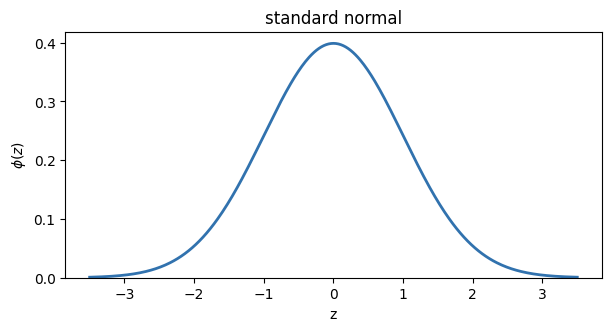

              from f(x)      notes
total            1.0000     1.0000
mean             0.0000     0.0000
variance         1.0000     1.0000


In [5]:
def standard_normal(z):
    return np.exp(-z**2 / 2) / math.sqrt(2 * math.pi)


z = np.linspace(-3.5, 3.5, 401)
curves(z, [standard_normal(z)], [None], "standard normal",
       xlabel="z", ylabel=r"$\phi(z)$")
plt.show()

z = np.linspace(-12, 12, 200001)
check(z, standard_normal(z), mean=0, variance=1)

## Normal

Mean $\mu\in\mathbb{R}$ and variance $\sigma^{2}>0$; $X\sim\mathcal{N}(\mu,\sigma^{2})$.

$$
f_X(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\Bigl(-\frac{(x-\mu)^{2}}{2\sigma^{2}}\Bigr),\qquad -\infty<x<\infty.
$$

* $\mathbb{E}[X]=\mu$
* $\mathbb{V}[X]=\sigma^{2}$
* $M_X(t)=\exp\bigl(\mu t+\sigma^{2}t^{2}/2\bigr)$ for all $t\in\mathbb{R}$

> If $X\sim\mathcal{N}(\mu,\sigma^{2})$, then $Z=(X-\mu)/\sigma\sim\mathcal{N}(0,1)$.

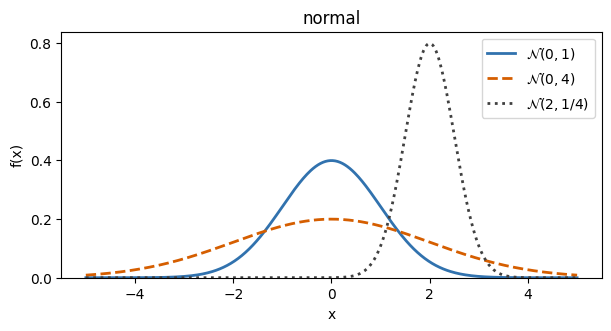

              from f(x)      notes
total            1.0000     1.0000
mean             2.0000     2.0000
variance         0.2500     0.2500


In [6]:
def normal(x, mu, sigma2):        # sigma2 is the variance
    return np.exp(-(x - mu)**2 / (2 * sigma2)) / math.sqrt(2 * math.pi * sigma2)


x = np.linspace(-5, 5, 401)
curves(x, [normal(x, 0, 1), normal(x, 0, 4), normal(x, 2, 0.25)],
       [r"$\mathcal{N}(0, 1)$", r"$\mathcal{N}(0, 4)$", r"$\mathcal{N}(2, 1/4)$"],
       "normal")
plt.show()

mu, sigma2 = 2, 0.25
sigma = math.sqrt(sigma2)
x = np.linspace(mu - 12 * sigma, mu + 12 * sigma, 200001)
check(x, normal(x, mu, sigma2), mean=mu, variance=sigma2)

## Chi-square

Degrees of freedom $n\in\{1,2,\dots\}$; $X\sim\chi^{2}_{n}$.

$$
f_X(x)=\frac{(1/2)^{n/2}}{\Gamma(n/2)}\,x^{n/2-1}e^{-x/2},\qquad x>0.
$$

* $\mathbb{E}[X]=n$
* $\mathbb{V}[X]=2n$
* $M_X(t)=(1-2t)^{-n/2}$ for $t<1/2$

> The chi-square distribution with $n$ degrees of freedom is the gamma distribution
> with $\alpha=n/2$ and $\lambda=1/2$.

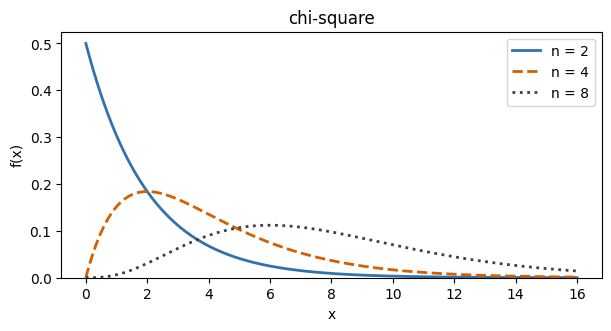

              from f(x)      notes
total            1.0000     1.0000
mean             4.0000     4.0000
variance         8.0000     8.0000


In [7]:
def chi_square(x, n):             # for x > 0
    return 0.5**(n / 2) / math.gamma(n / 2) * x**(n / 2 - 1) * np.exp(-x / 2)


x = np.linspace(0, 16, 401)
curves(x, [chi_square(x, 2), chi_square(x, 4), chi_square(x, 8)],
       ["n = 2", "n = 4", "n = 8"], "chi-square")
plt.show()

n = 4
x = np.linspace(0, 200, 200001)
check(x, chi_square(x, n), mean=n, variance=2 * n)

## Beta

Parameters $a>0$ and $b>0$.

$$
f_X(x)=\frac{\Gamma(a+b)}{\Gamma(a)\Gamma(b)}\,x^{a-1}(1-x)^{b-1},\qquad 0<x<1.
$$

* $\mathbb{E}[X]=\dfrac{a}{a+b}$
* $\mathbb{V}[X]=\dfrac{ab}{(a+b)^{2}(a+b+1)}$

> The beta distribution with $a=b=1$ is the uniform distribution on $(0,1)$.

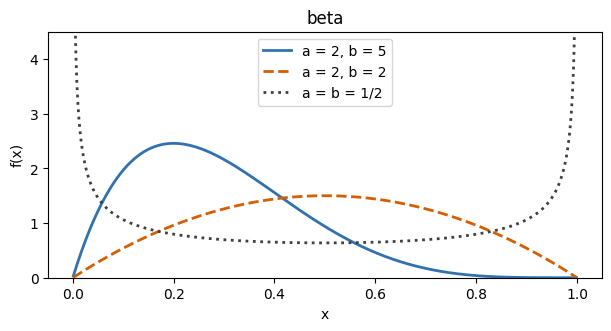

              from f(x)      notes
total            1.0000     1.0000
mean             0.2857     0.2857
variance         0.0255     0.0255


In [8]:
def beta(x, a, b):                # for 0 < x < 1
    return (math.gamma(a + b) / (math.gamma(a) * math.gamma(b))
            * x**(a - 1) * (1 - x)**(b - 1))


x = np.linspace(0.001, 0.999, 999)   # the a = b = 1/2 density is infinite at 0 and 1
ax = curves(x, [beta(x, 2, 5), beta(x, 2, 2), beta(x, 0.5, 0.5)],
            ["a = 2, b = 5", "a = 2, b = 2", "a = b = 1/2"], "beta")
ax.set_ylim(0, 4.5)
plt.show()

a, b = 2, 5
x = np.linspace(0, 1, 200001)
check(x, beta(x, a, b), mean=a / (a + b), variance=a * b / ((a + b)**2 * (a + b + 1)))

## Built-in functions

In your own code you will usually call the built-in densities in `scipy.stats` instead
of typing in the formulas. Several of them take different parameters than the notes:
`stats.norm` takes the standard deviation $\sigma$ rather than the variance, and
`stats.expon` and `stats.gamma` take the scale $1/\lambda$ rather than the rate. The
table in [`README.md`](README.md) gives the call that matches each $f_X(x)$ above.

---
This notebook is part of STAN (Statistics: Theory, Applications & Numerics), the code
repository for MATH 166 at Tufts University: <https://github.com/andreasmang/stan>